# Phase 4: ENSO Impact Analysis

This notebook investigates the relationship between NOAA ONI and California coast SST anomalies.

Unlike the initial EDA, this analysis uses SST anomalies rather than raw SST, which removes the seasonal cycle and gives a more meaningful ENSO relationship.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("..").resolve()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

MHW_DAILY_PATH = PROCESSED_DIR / "mhw_daily_labeled_1982_2024.csv"
ONI_PATH = PROCESSED_DIR / "oni_monthly.csv"

daily = pd.read_csv(MHW_DAILY_PATH)
oni = pd.read_csv(ONI_PATH)

daily["date"] = pd.to_datetime(daily["date"])
oni["date"] = pd.to_datetime(oni["date"])

daily.head()

,date,year,sst,day_of_year,climatological_mean,threshold,sst_anomaly,threshold_anomaly,above_threshold,mhw_event_id
0,1982-01-01,1982,14.619334,1,14.419488,15.299240,0.199846,0.879752,False,NaN
1,1982-01-02,1982,14.521364,2,14.419681,15.192833,0.101683,0.773153,False,NaN
2,1982-01-03,1982,14.399932,3,14.427253,15.185508,-0.027321,0.758255,False,NaN
3,1982-01-04,1982,14.327671,4,14.422400,15.201450,-0.094729,0.779050,False,NaN
4,1982-01-05,1982,14.418211,5,14.389955,15.262431,0.028256,0.872476,False,NaN


In [3]:
print("Daily shape:", daily.shape)
print("ONI shape:", oni.shape)

print("\nDaily columns:")
print(daily.columns.tolist())

print("\nMissing values in key columns:")
print(daily[["date", "sst", "sst_anomaly", "above_threshold"]].isna().sum())

print("\nDate range:")
print(daily["date"].min(), "to", daily["date"].max())


Daily shape: (15695, 10)
ONI shape: (917, 7)

Daily columns:
['date', 'year', 'sst', 'day_of_year', 'climatological_mean', 'threshold', 'sst_anomaly', 'threshold_anomaly', 'above_threshold', 'mhw_event_id']

Missing values in key columns:
date               0
sst                0
sst_anomaly        0
above_threshold    0
dtype: int64

Date range:
1982-01-01 00:00:00 to 2024-12-31 00:00:00


In [4]:
# 聚合到月度 SST anomaly
monthly_anomaly = (
    daily.set_index("date")
    .resample("MS")
    .agg(
        sst=("sst", "mean"),
        sst_anomaly=("sst_anomaly", "mean"),
        mhw_days=("mhw_event_id", lambda x: x.notna().sum()),
    )
    .reset_index()
)

monthly_anomaly["year"] = monthly_anomaly["date"].dt.year
monthly_anomaly["month"] = monthly_anomaly["date"].dt.month

monthly_anomaly.head()


,date,sst,sst_anomaly,mhw_days,year,month
0,1982-01-01,14.045085,-0.157303,0,1982,1
1,1982-02-01,13.897722,-0.113589,0,1982,2
2,1982-03-01,13.945116,-0.105309,0,1982,3
3,1982-04-01,14.433332,0.180299,0,1982,4
4,1982-05-01,14.463608,-0.342588,0,1982,5


In [5]:
# 合并 ONI
enso = monthly_anomaly.merge(oni[["date", "oni", "enso_phase"]], on="date", how="left")

print("Merged shape:", enso.shape)
print("Missing ONI:", enso["oni"].isna().sum())

enso.head()


Merged shape: (516, 8)
Missing ONI: 0


,date,sst,sst_anomaly,mhw_days,year,month,oni,enso_phase
0,1982-01-01,14.045085,-0.157303,0,1982,1,-0.05,Neutral
1,1982-02-01,13.897722,-0.113589,0,1982,2,0.07,Neutral
2,1982-03-01,13.945116,-0.105309,0,1982,3,0.19,Neutral
3,1982-04-01,14.433332,0.180299,0,1982,4,0.47,Neutral
4,1982-05-01,14.463608,-0.342588,0,1982,5,0.66,El Niño


In [6]:
# 保存基础 ENSO 数据
enso_path = PROCESSED_DIR / "monthly_sst_anomaly_oni_1982_2024.csv"
enso.to_csv(enso_path, index=False)

print("Saved:", enso_path)

Saved: /Users/sumi/Desktop/project/data/processed/monthly_sst_anomaly_oni_1982_2024.csv


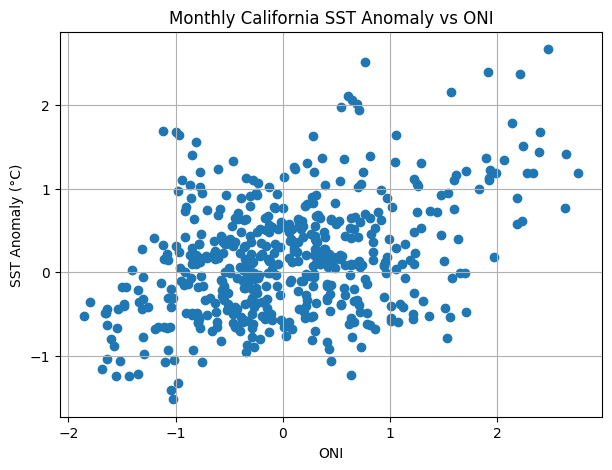

In [7]:
# ONI vs SST anomaly 散点图
plt.figure(figsize=(7, 5))
plt.scatter(enso["oni"], enso["sst_anomaly"])
plt.title("Monthly California SST Anomaly vs ONI")
plt.xlabel("ONI")
plt.ylabel("SST Anomaly (°C)")
plt.grid(True)
plt.show()


In [8]:
# 计算相关性
corr_anom = enso[["oni", "sst_anomaly"]].corr().loc["oni", "sst_anomaly"]
corr_raw = enso[["oni", "sst"]].corr().loc["oni", "sst"]

print(f"Correlation between ONI and raw monthly SST: {corr_raw:.3f}")
print(f"Correlation between ONI and monthly SST anomaly: {corr_anom:.3f}")

Correlation between ONI and raw monthly SST: 0.169
Correlation between ONI and monthly SST anomaly: 0.409


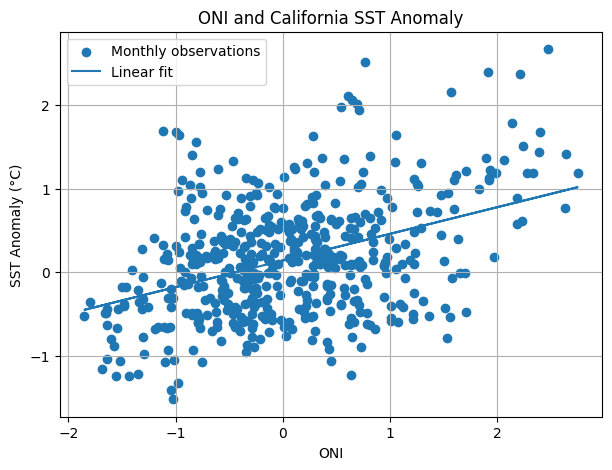

Slope: 0.318 °C anomaly per 1 ONI unit
Intercept: 0.142


In [9]:
# 加回归线
x = enso["oni"].values
y = enso["sst_anomaly"].values

mask = ~np.isnan(x) & ~np.isnan(y)
x_clean = x[mask]
y_clean = y[mask]

slope, intercept = np.polyfit(x_clean, y_clean, 1)
y_pred = intercept + slope * x_clean

plt.figure(figsize=(7, 5))
plt.scatter(x_clean, y_clean, label="Monthly observations")
plt.plot(x_clean, y_pred, label="Linear fit")

plt.title("ONI and California SST Anomaly")
plt.xlabel("ONI")
plt.ylabel("SST Anomaly (°C)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Slope: {slope:.3f} °C anomaly per 1 ONI unit")
print(f"Intercept: {intercept:.3f}")

In [10]:
# 按 ENSO 阶段比较 SST anomaly
enso_phase_summary = (
    enso.groupby("enso_phase")["sst_anomaly"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)

enso_phase_summary


,enso_phase,count,mean,std,min,max
0,El Niño,143,0.473169,0.806667,-1.228552,2.667190
1,La Niña,144,-0.093496,0.655601,-1.515991,1.686504
2,Neutral,229,0.117967,0.534276,-1.061577,1.625108


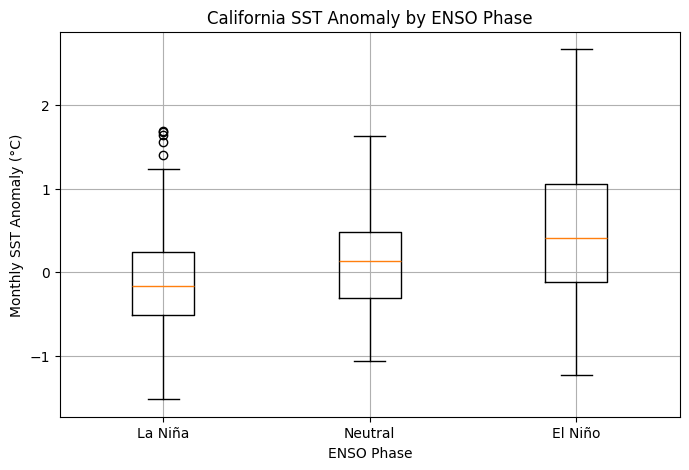

In [11]:
# ENSO 阶段箱线图
phase_order = ["La Niña", "Neutral", "El Niño"]

data_to_plot = [
    enso.loc[enso["enso_phase"] == phase, "sst_anomaly"].dropna()
    for phase in phase_order
]

plt.figure(figsize=(8, 5))
plt.boxplot(data_to_plot, tick_labels=phase_order)
plt.title("California SST Anomaly by ENSO Phase")
plt.xlabel("ENSO Phase")
plt.ylabel("Monthly SST Anomaly (°C)")
plt.grid(True)
plt.show()


In [12]:
# Lag correlation
lag_results = []

for lag in range(-12, 13):
    temp = enso.copy()

    # Positive lag means ONI leads SST anomaly
    temp["oni_lagged"] = temp["oni"].shift(lag)

    corr = temp[["oni_lagged", "sst_anomaly"]].corr().loc["oni_lagged", "sst_anomaly"]

    lag_results.append(
        {
            "lag_months": lag,
            "correlation": corr,
        }
    )

lag_corr = pd.DataFrame(lag_results)

lag_corr


,lag_months,correlation
0,-12,0.107209
1,-11,0.117111
2,-10,0.122059
3,-9,0.128954
4,-8,0.141996
5,-7,0.166383
6,-6,0.198538
7,-5,0.234984
8,-4,0.272814
9,-3,0.308977


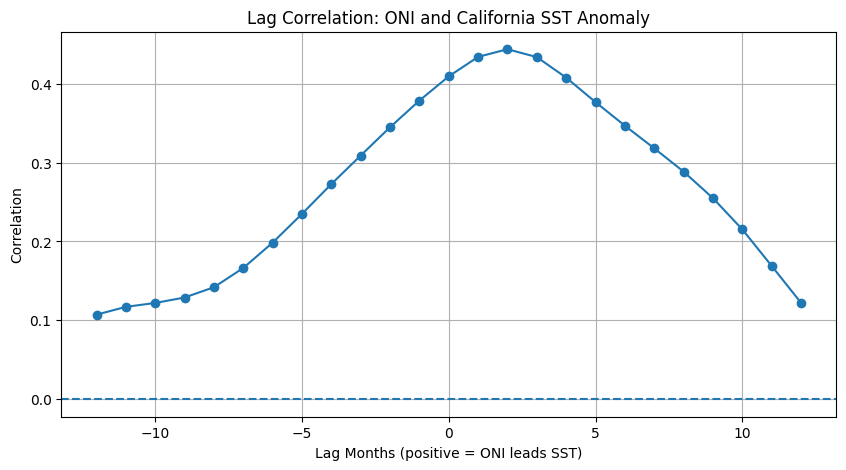

Best lag: 2 months
Correlation: 0.444


In [16]:
# 绘制 Lag correlation
plt.figure(figsize=(10, 5))
plt.plot(lag_corr["lag_months"], lag_corr["correlation"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Lag Correlation: ONI and California SST Anomaly")
plt.xlabel("Lag Months (positive = ONI leads SST)")
plt.ylabel("Correlation")
plt.grid(True)
plt.show()

best_lag = lag_corr.loc[lag_corr["correlation"].abs().idxmax()]

print(f"Best lag: {int(best_lag['lag_months'])} months")
print(f"Correlation: {best_lag['correlation']:.3f}")

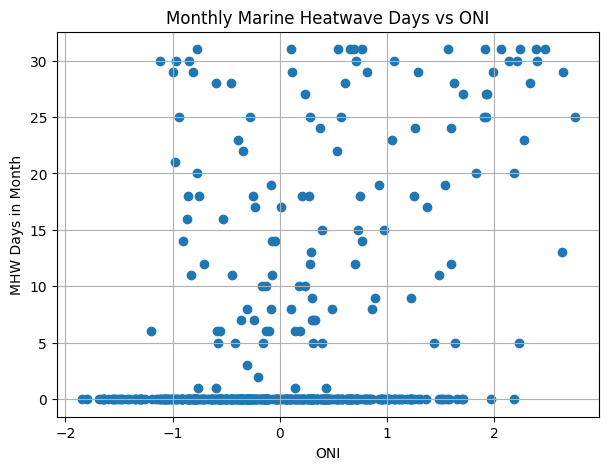

Correlation between ONI and monthly MHW days: 0.355


In [17]:
# MHW days 和 ONI 的关系
plt.figure(figsize=(7, 5))
plt.scatter(enso["oni"], enso["mhw_days"])
plt.title("Monthly Marine Heatwave Days vs ONI")
plt.xlabel("ONI")
plt.ylabel("MHW Days in Month")
plt.grid(True)
plt.show()

corr_mhw_oni = enso[["oni", "mhw_days"]].corr().loc["oni", "mhw_days"]

print(f"Correlation between ONI and monthly MHW days: {corr_mhw_oni:.3f}")


In [15]:
# 按 ENSO 阶段比较 MHW days
mhw_by_phase = (
    enso.groupby("enso_phase")["mhw_days"]
    .agg(["count", "mean", "std", "min", "max"])
    .reset_index()
)

mhw_by_phase


,enso_phase,count,mean,std,min,max
0,El Niño,143,8.538462,12.092815,0,31
1,La Niña,144,2.798611,7.582257,0,31
2,Neutral,229,2.611354,6.253564,0,31


In [18]:
lag_corr_path = PROCESSED_DIR / "enso_lag_correlation_1982_2024.csv"
phase_summary_path = PROCESSED_DIR / "enso_phase_sst_anomaly_summary_1982_2024.csv"
mhw_phase_summary_path = PROCESSED_DIR / "enso_phase_mhw_summary_1982_2024.csv"

lag_corr.to_csv(lag_corr_path, index=False)
enso_phase_summary.to_csv(phase_summary_path, index=False)
mhw_by_phase.to_csv(mhw_phase_summary_path, index=False)

print("Saved:", lag_corr_path)
print("Saved:", phase_summary_path)
print("Saved:", mhw_phase_summary_path)


Saved: /Users/sumi/Desktop/project/data/processed/enso_lag_correlation_1982_2024.csv
Saved: /Users/sumi/Desktop/project/data/processed/enso_phase_sst_anomaly_summary_1982_2024.csv
Saved: /Users/sumi/Desktop/project/data/processed/enso_phase_mhw_summary_1982_2024.csv
